# 037 Effective Topology Analysis

Fully-connected (FC) runs are nominally symmetric — every agent reads every other.
But in practice, influence is uneven. We build a directed weighted influence graph
W[i→j] per repetition (vote-flip credit from `dominance.py`) and ask:

- Does FC self-organise into a **star-like** structure?
- Are there other emergent shapes: **two-hub**, **chain**, **flat**?
- Does topology type predict accuracy?
- Is the hub the agent that started with the correct answer?

**Data:** `results/mas/final_dataset_new_system/*_fc/`  (N=4, T=15, W∈{1,2,5})


In [22]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy import stats as sp_stats

from src.metrics.dominance import _influence_graph
from src.viz.thesis_style import apply_style, W_COLORS, DS_COLORS, DS_LABELS

apply_style()
BASE = Path('..') / 'results' / 'mas' / 'final_dataset_new_system'

In [23]:
def topology_type(p_sorted, N):
    p0, p1 = p_sorted[0], p_sorted[1] if N > 1 else 0.0
    if p0 >= 0.75:
        return 'star'
    if p0 < 0.60 and p1 > 0 and p1 / p0 > 0.65:
        return 'two-hub'
    if p0 >= 0.45:
        return 'hub'
    return 'flat'


records = []
traj_store = []

for f in sorted(BASE.glob('*_fc/*.json')):
    d = json.loads(f.read_text())
    ds      = d['dataset']
    W_param = d['W']
    qid     = d['question_id']
    gt      = d['ground_truth']

    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        N    = len(traj[0]['phase_b'])
        W_mat = _influence_graph(rep)
        s    = W_mat.sum(axis=1)
        total = float(s.sum())

        if total > 0:
            p        = s / total
            p_sorted = np.sort(p)[::-1]
            D        = float((np.dot(p, p) - 1/N) / (1 - 1/N))
            ttype    = topology_type(p_sorted, N)
        else:
            p_sorted = np.full(N, 1.0/N)
            D        = 0.0
            ttype    = 'degenerate'

        hub_idx       = int(np.argmax(s))
        init_votes    = [traj[0]['phase_b'][ag]['vote'] for ag in range(N)]
        final_votes   = [traj[-1]['phase_b'][ag]['vote'] for ag in range(N)]

        row_idx = len(records)
        records.append({
            'row_idx':          row_idx,
            'dataset':          ds,
            'W_param':          W_param,
            'qid':              qid,
            'rep_idx':          rep_idx,
            'correct':          int(rep['correct']),
            'n_rounds':         len(traj) - 1,
            'total_influence':  total,
            'hub_frac':         float(p_sorted[0]),
            'second_frac':      float(p_sorted[1]) if N > 1 else 0.0,
            'D':                D,
            'hub_idx':          hub_idx,
            'hub_init_correct': int(init_votes[hub_idx] == gt),
            'hub_final_correct':int(final_votes[hub_idx] == gt),
            'ttype':            ttype,
            'p_sorted':         p_sorted.tolist(),
            'W_mat':            W_mat.tolist(),
            'init_votes':       init_votes,
            'gt':               gt,
        })
        traj_store.append(traj)

df      = pd.DataFrame(records)
df_valid = df[df['total_influence'] > 0].copy()

print(f'FC reps total:  {len(df):,}')
print(f'Valid (≥1 flip): {len(df_valid):,}  ({100*len(df_valid)/len(df):.1f}%)')
print()
print(df_valid.groupby(['dataset','W_param'])['hub_frac'].describe().round(3).to_string())

FC reps total:  12,750
Valid (≥1 flip): 10,729  (84.1%)

                      count   mean    std    min    25%    50%  75%  max
dataset     W_param                                                     
gpqa        1        1954.0  0.422  0.126  0.262  0.333  0.375  0.5  1.0
            2        1933.0  0.418  0.124  0.263  0.333  0.367  0.5  1.0
            5        1916.0  0.422  0.126  0.250  0.333  0.374  0.5  1.0
hiddenbench 1        1643.0  0.439  0.140  0.261  0.333  0.408  0.5  1.0
            2        1646.0  0.457  0.152  0.265  0.333  0.417  0.5  1.0
            5        1637.0  0.458  0.149  0.250  0.333  0.417  0.5  1.0


## 1 · Hub-fraction distribution

`hub_frac` = share of total vote-flip influence captured by the single most influential agent.
Uniform FC → 0.25; pure star → 1.0.

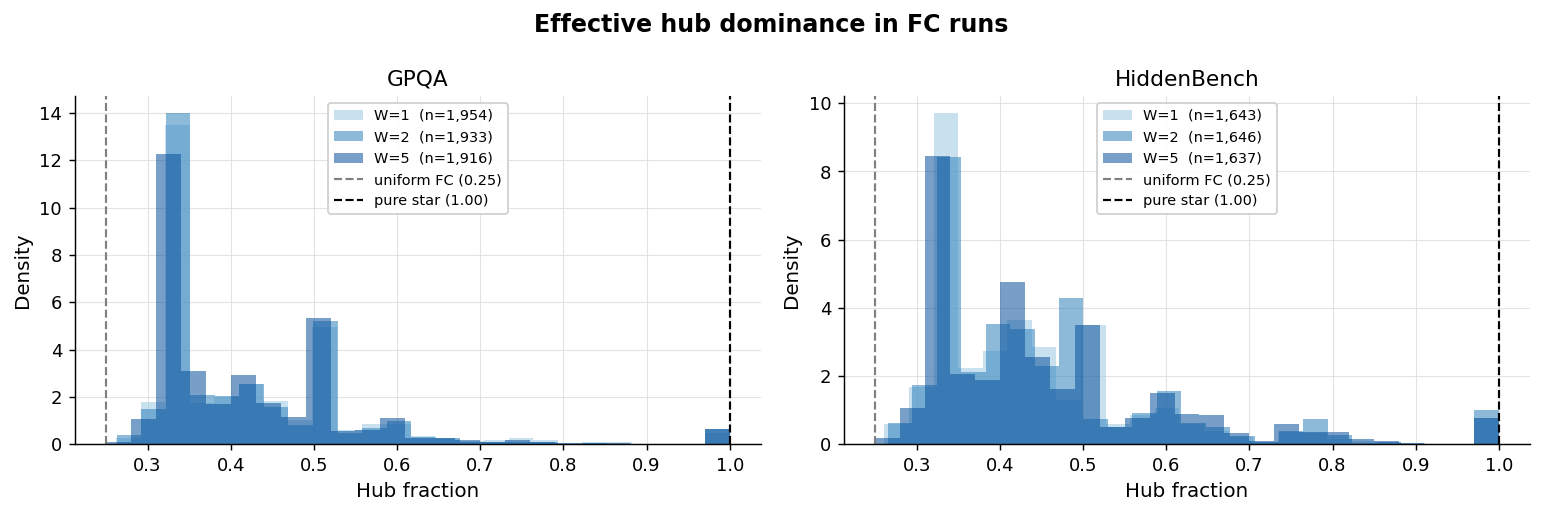

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub = df_valid[df_valid['dataset'] == ds]
    for w in [1, 2, 5]:
        vals = sub[sub['W_param'] == w]['hub_frac']
        ax.hist(vals, bins=25, alpha=0.55, density=True,
                label=f'W={w}  (n={len(vals):,})', color=W_COLORS[w])
    ax.axvline(0.25, ls='--', lw=1.2, color='grey',  label='uniform FC (0.25)')
    ax.axvline(1.00, ls='--', lw=1.2, color='black', label='pure star (1.00)')
    ax.set_xlabel('Hub fraction')
    ax.set_ylabel('Density')
    ax.set_title(f'{DS_LABELS[ds]}')
    ax.legend(fontsize=8)

fig.suptitle('Effective hub dominance in FC runs', fontweight='bold')
plt.tight_layout()
plt.show()

## 2 · Topology-type breakdown

In [25]:
TYPE_ORDER  = ['flat', 'hub', 'two-hub', 'star', 'degenerate']
TYPE_COLORS = {'flat': '#95a5a6', 'hub': '#3498db', 'two-hub': '#9b59b6',
               'star': '#e74c3c', 'degenerate': '#ecf0f1'}

counts = df.groupby(['dataset', 'W_param', 'ttype']).size().unstack(fill_value=0)
counts = counts.reindex(columns=[t for t in TYPE_ORDER if t in counts.columns])
pcts   = counts.div(counts.sum(axis=1), axis=0) * 100

print('Topology type fractions (%) — including degenerate:')
print(pcts.round(1).to_string())
print()
print('Valid-only topology type fractions (%):')
pcts_v = df_valid.groupby(['dataset', 'W_param', 'ttype']).size().unstack(fill_value=0)
pcts_v = pcts_v.reindex(columns=[t for t in TYPE_ORDER if t in pcts_v.columns])
pcts_v = pcts_v.div(pcts_v.sum(axis=1), axis=0) * 100
print(pcts_v.round(1).to_string())

Topology type fractions (%) — including degenerate:
ttype                flat   hub  two-hub  star  degenerate
dataset     W_param                                       
gpqa        1         5.4  11.6     58.6   2.5        21.8
            2         5.0  10.4     59.8   2.0        22.7
            5         5.8  10.9     57.7   2.2        23.4
hiddenbench 1         7.4  18.0     63.8   4.7         6.1
            2         7.5  19.5     60.3   6.7         5.9
            5         7.7  20.6     59.3   6.0         6.5

Valid-only topology type fractions (%):
ttype                flat   hub  two-hub  star
dataset     W_param                           
gpqa        1         6.9  14.9     75.0   3.2
            2         6.5  13.5     77.4   2.6
            5         7.6  14.2     75.3   2.9
hiddenbench 1         7.9  19.2     67.9   5.0
            2         8.0  20.8     64.1   7.1
            5         8.2  22.1     63.3   6.4


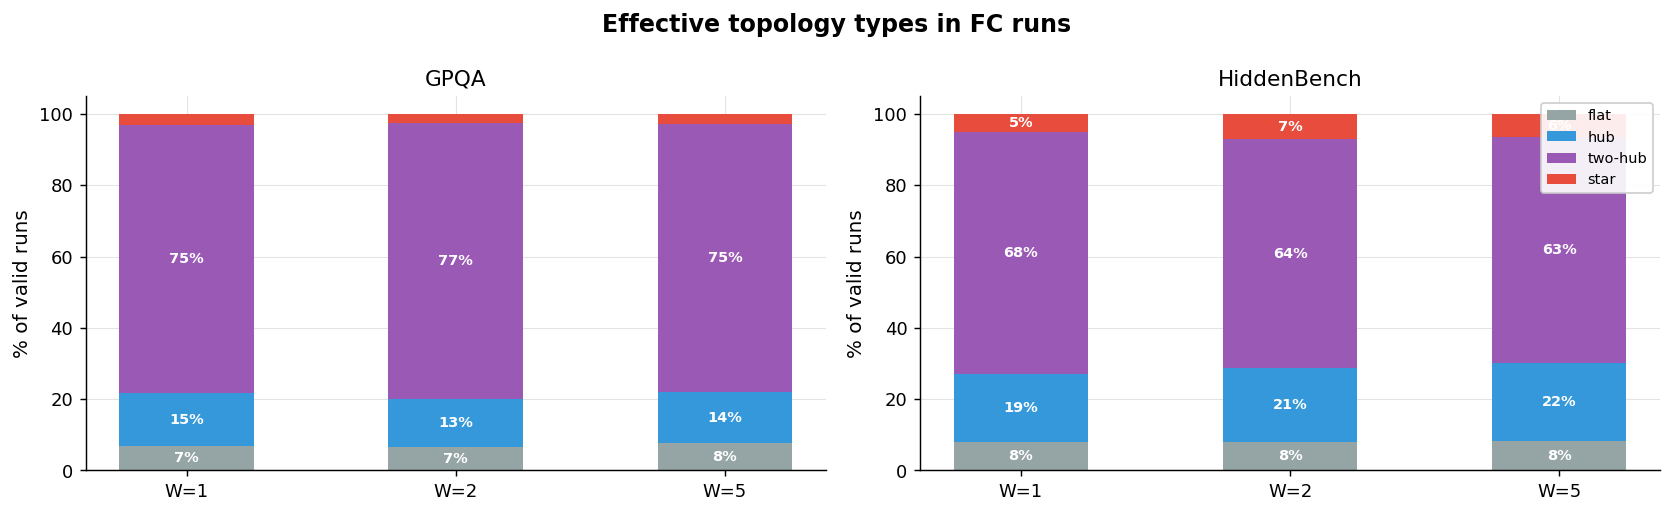

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub_pcts = pcts_v.loc[ds] if ds in pcts_v.index.get_level_values(0) else pcts_v.xs(ds)
    bottom   = np.zeros(len(sub_pcts))
    x_labels = [f'W={w}' for w in sub_pcts.index]
    x        = np.arange(len(x_labels))

    for ttype in [t for t in TYPE_ORDER if t in sub_pcts.columns]:
        vals = sub_pcts[ttype].values
        ax.bar(x, vals, bottom=bottom, color=TYPE_COLORS[ttype], label=ttype, width=0.5)
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('% of valid runs')
    ax.set_title(f'{DS_LABELS[ds]}')
    ax.set_ylim(0, 105)
    if ax == axes[1]:
        ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Effective topology types in FC runs', fontweight='bold')
plt.tight_layout()
plt.show()

## 3 · Network visualisations

In [27]:
HUB_COLOR     = '#e67e22'  # orange — hub (most influential)
DEFAULT_COLOR = '#3498db'  # blue  — non-hub
CORRECT_BORDER = '#27ae60' # green border — agent started with correct answer
DEFAULT_BORDER = '#95a5a6' # grey border  — did not start correct


def draw_effective_network(W_mat, ax, title='', correct=None, gt=None, init_votes=None):
    W  = np.array(W_mat, dtype=float)
    N  = len(W)
    s  = W.sum(axis=1)
    total = s.sum()

    angles = [np.pi/2 + 2*np.pi*i/N for i in range(N)]
    pos    = {i: (np.cos(angles[i]), np.sin(angles[i])) for i in range(N)}

    hub   = int(np.argmax(s))
    W_max = W.max() if W.max() > 0 else 1.0

    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    for i in range(N):
        for j in range(N):
            if i != j and W[i, j] > 1e-9:
                G.add_edge(i, j, weight=W[i, j])

    node_colors  = [HUB_COLOR if (total > 0 and i == hub) else DEFAULT_COLOR for i in range(N)]
    border_colors = [CORRECT_BORDER if (init_votes is not None and gt is not None and init_votes[i] == gt)
                     else DEFAULT_BORDER for i in range(N)]
    node_sizes   = [350 + 900 * (s[i]/total if total > 0 else 1/N) for i in range(N)]

    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(range(N)),
                           node_color=node_colors, node_size=node_sizes,
                           edgecolors=border_colors, linewidths=3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white',
                            font_size=8, font_weight='bold')

    edges = list(G.edges())
    if edges:
        widths = [3.5 * G[u][v]['weight'] / W_max for u, v in edges]
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges, width=widths,
                               edge_color='#2c3e50', alpha=0.65, arrows=True,
                               arrowsize=14, connectionstyle='arc3,rad=0.15',
                               min_source_margin=18, min_target_margin=18)

    hub_pct  = 100 * s[hub] / total if total > 0 else 25.0
    p_sorted = np.sort(s / total if total > 0 else np.full(N, 1/N))[::-1]
    ttype    = topology_type(p_sorted, N) if total > 0 else 'degen.'
    c_str    = ' +' if correct == 1 else (' -' if correct == 0 else '')
    ax.set_title(f'{title}\n[{ttype}] hub={hub} {hub_pct:.0f}%{c_str}', fontsize=7)
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    ax.axis('off')

### 3a · One question, all topology types across reps

Pick a question with many valid reps and show a 5×8 grid coloured by topology type.

Question 2  —  40 reps shown
Type counts: {'two-hub': 26, 'hub': 8, 'flat': 6}


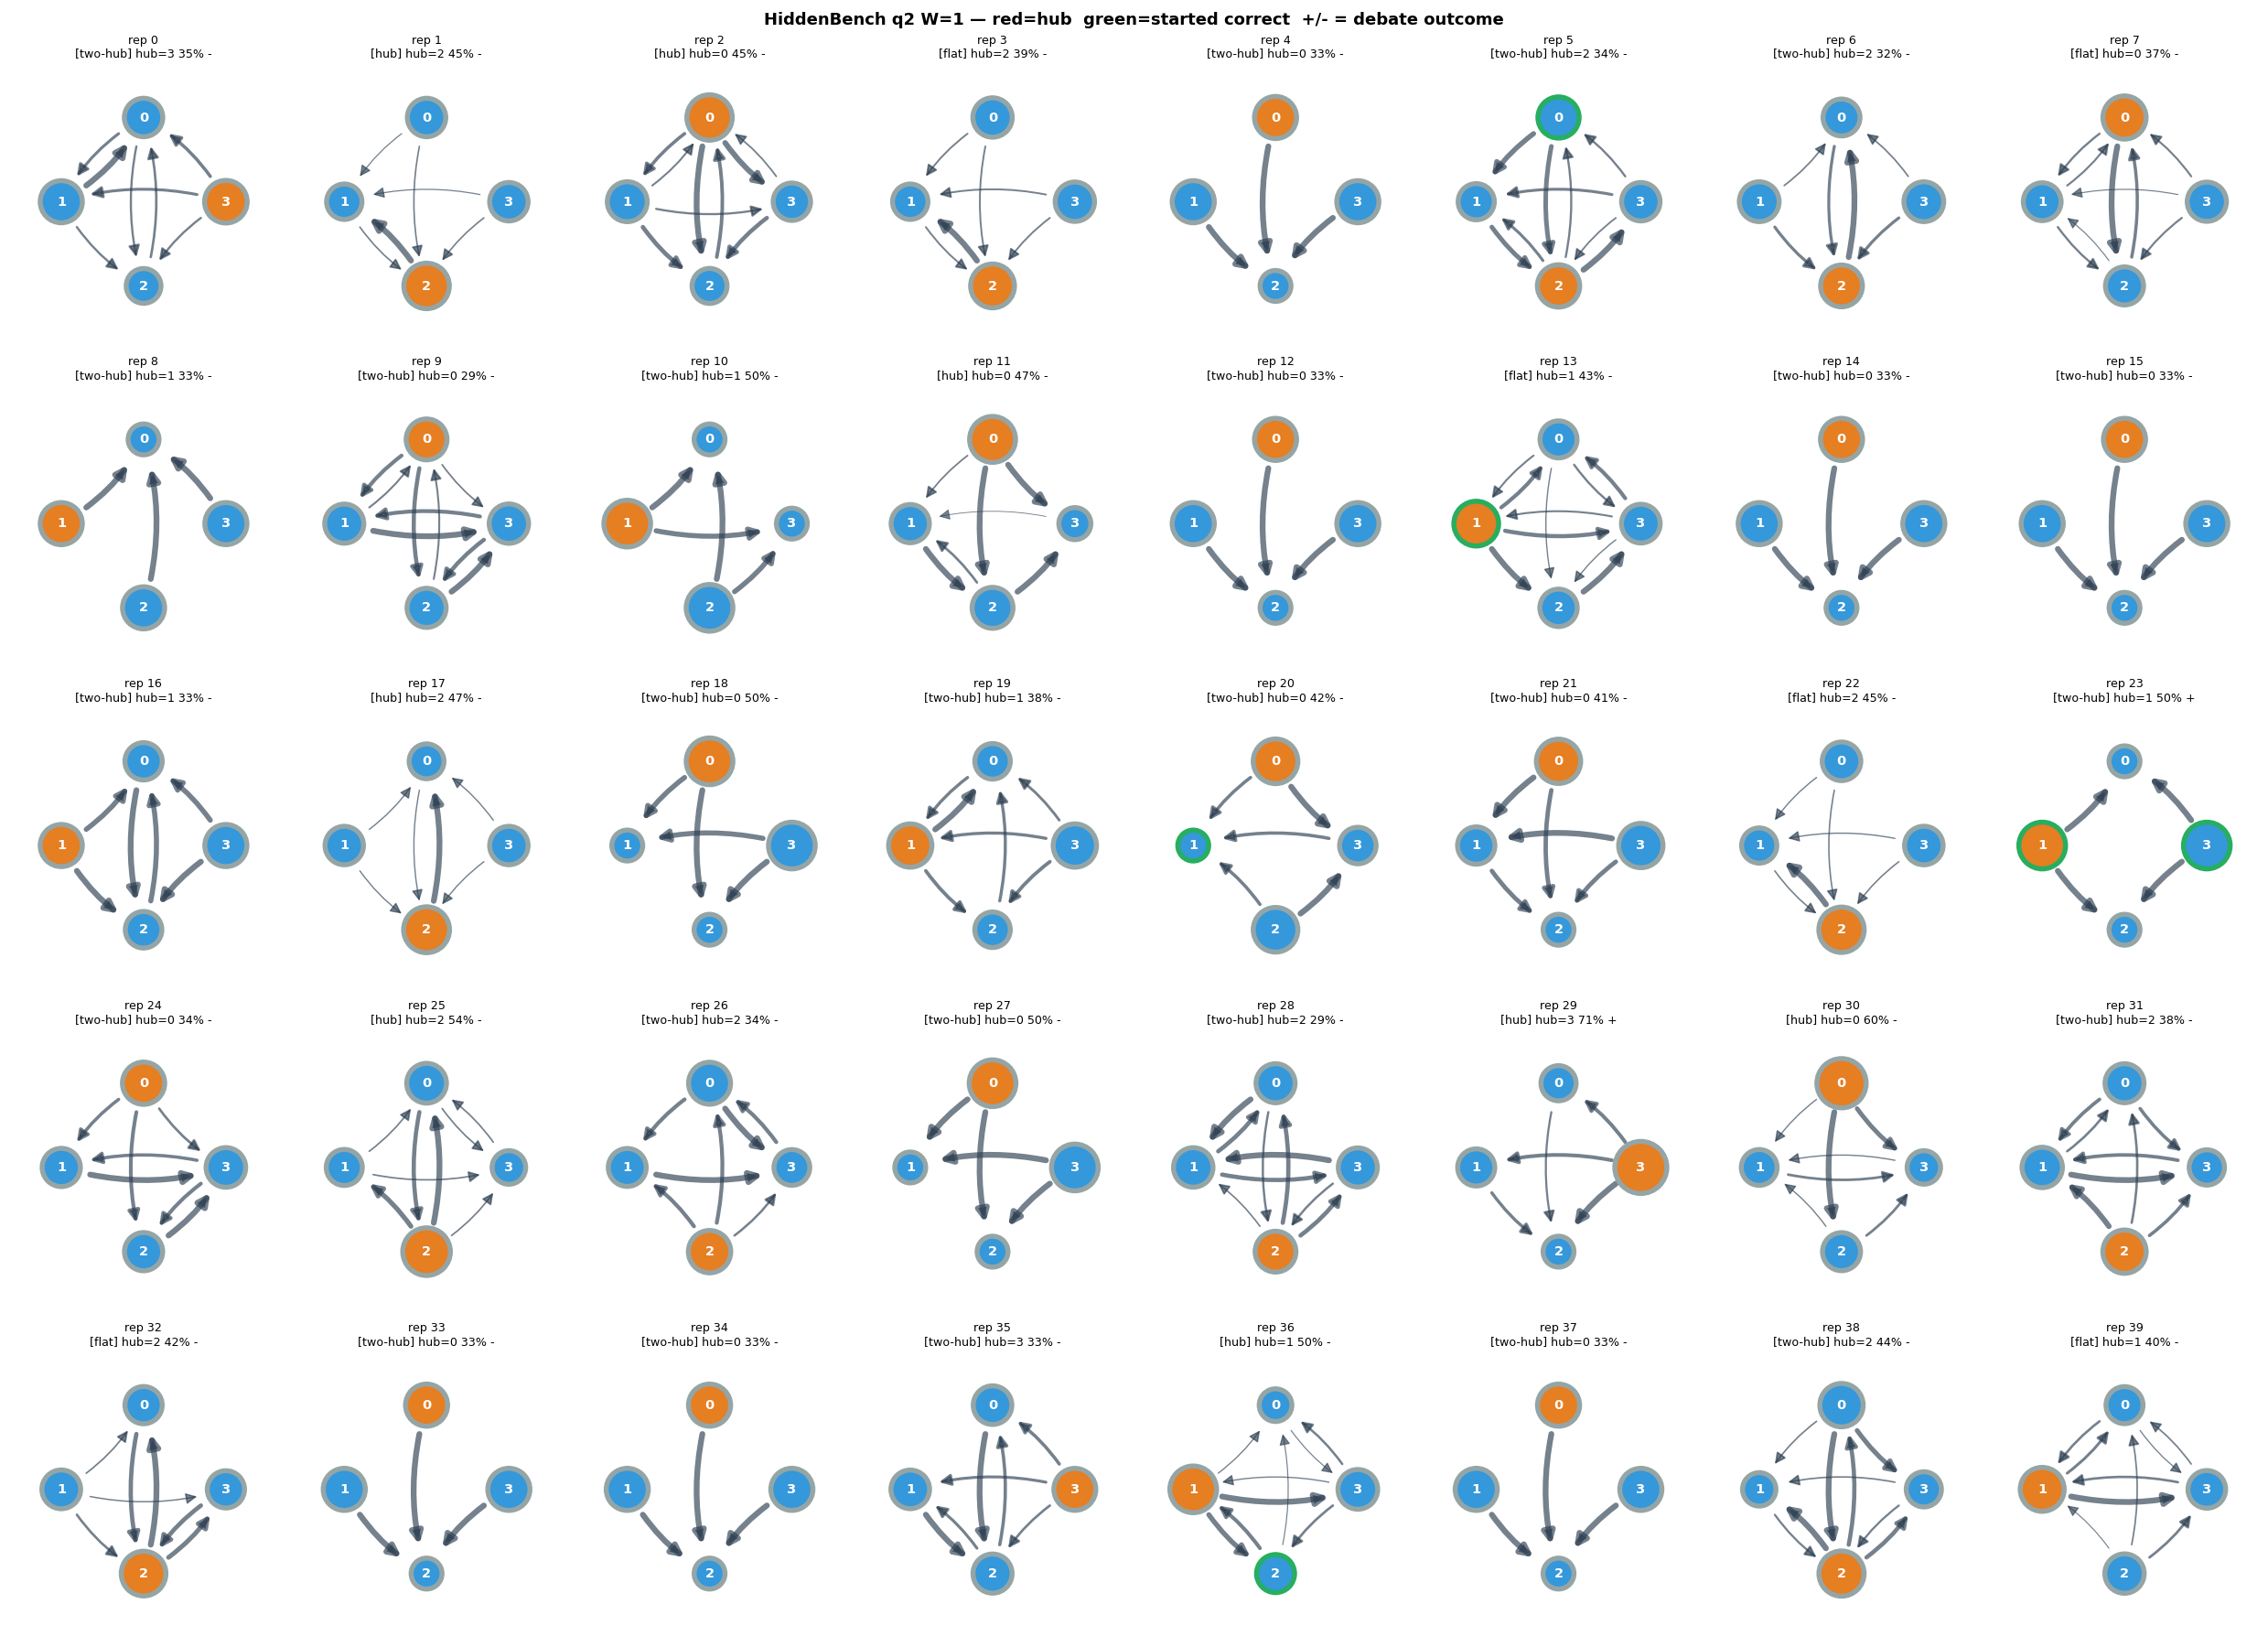

In [28]:
target_qid = df_valid[df_valid['dataset'] == 'hiddenbench']['qid'].value_counts().idxmax()
sample     = df_valid[(df_valid['dataset'] == 'hiddenbench') &
                      (df_valid['qid'] == target_qid) &
                      (df_valid['W_param'] == 1)].head(40)
print(f'Question {target_qid}  —  {len(sample)} reps shown')
print('Type counts:', sample['ttype'].value_counts().to_dict())

nrows, ncols = 5, 8
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.4, nrows*2.8))

for ax_idx, (_, row) in enumerate(sample.iterrows()):
    ax = axes[ax_idx // ncols][ax_idx % ncols]
    draw_effective_network(
        row['W_mat'], ax,
        title=f'rep {row["rep_idx"]}',
        correct=row['correct'],
        gt=row['gt'],
        init_votes=row['init_votes'],
    )

for extra in range(len(sample), nrows*ncols):
    axes[extra // ncols][extra % ncols].axis('off')

fig.suptitle(f'HiddenBench q{target_qid} W=1 — red=hub  green=started correct  +/- = debate outcome',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

### 3b · Topology-type exemplars (best examples of each type)

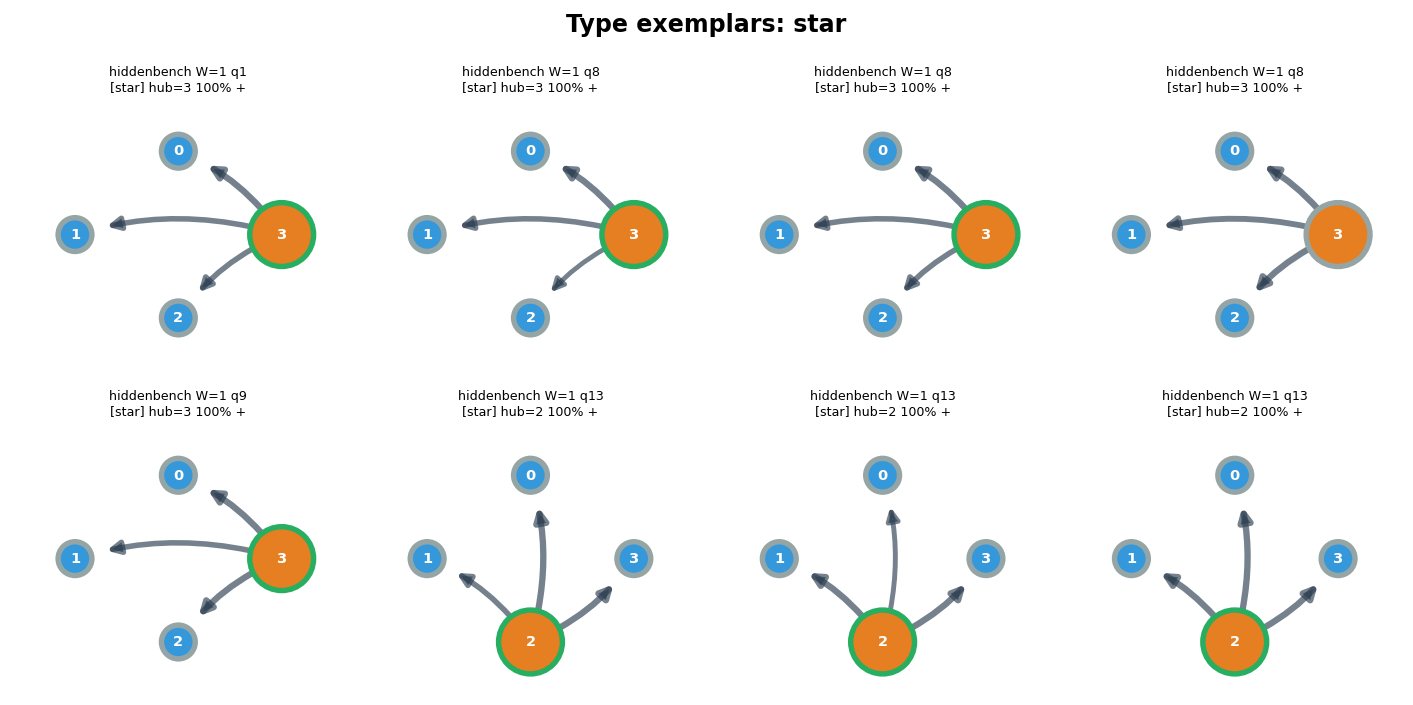

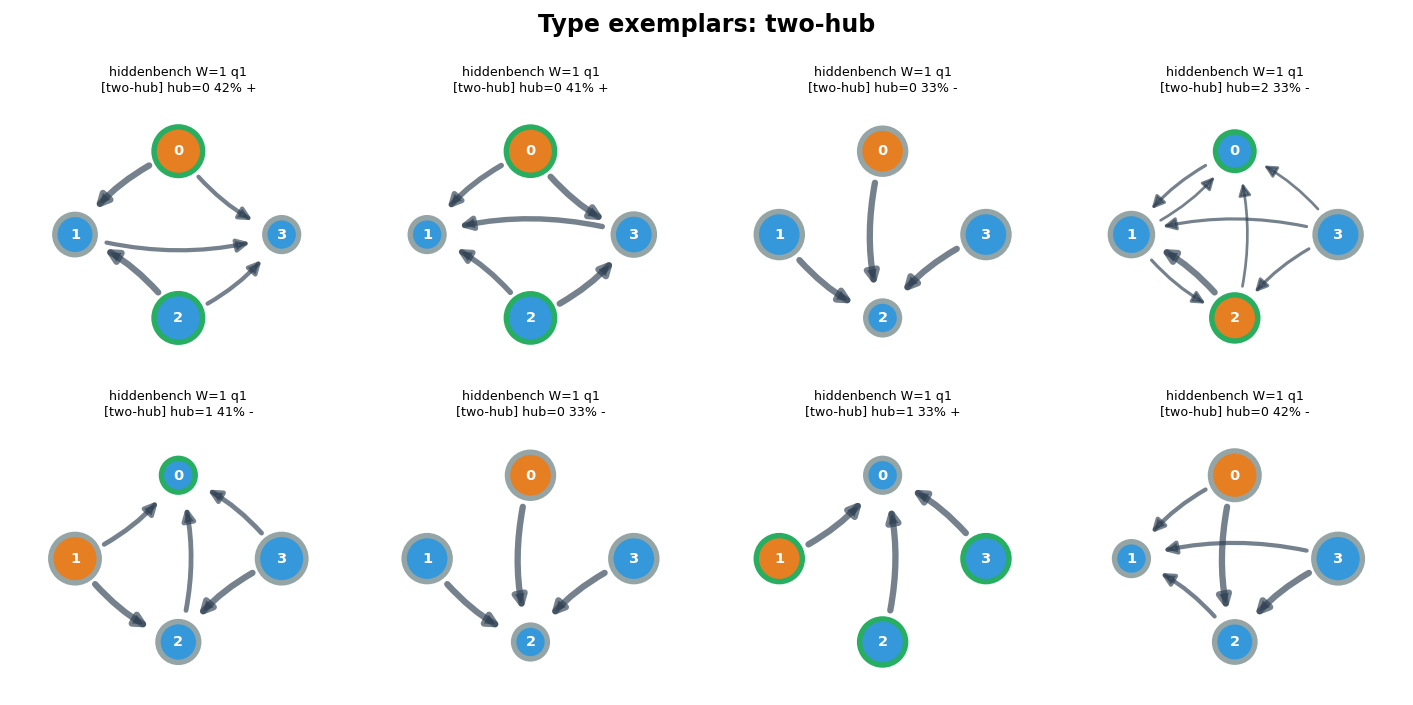

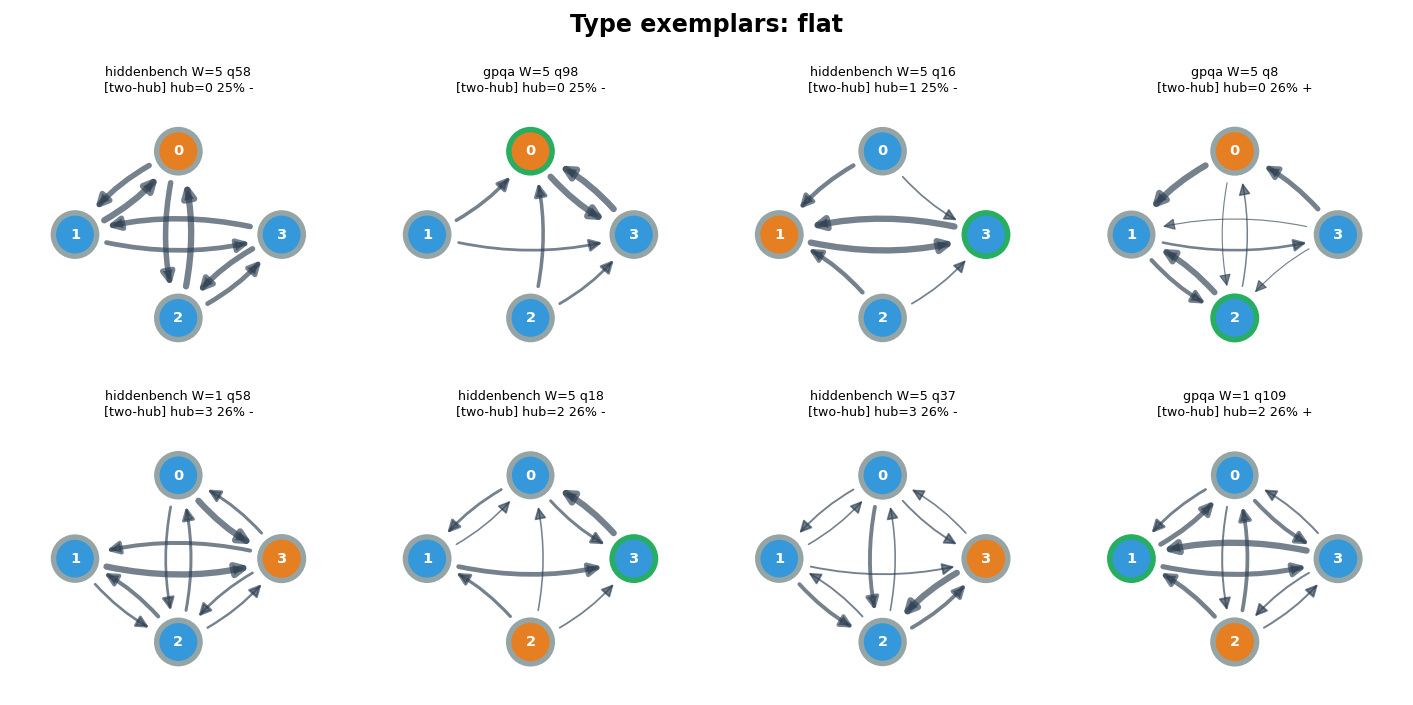

In [29]:
TYPE_SELECTORS = {
    'star':    df_valid.nlargest(8, 'hub_frac'),
    'two-hub': df_valid[df_valid['ttype'] == 'two-hub'].assign(
                   ratio=lambda x: x['second_frac'] / x['hub_frac']
               ).nlargest(8, 'ratio'),
    'flat':    df_valid.nsmallest(8, 'hub_frac'),
}

for ttype_name, subset in TYPE_SELECTORS.items():
    fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
    for ax_idx, (_, row) in enumerate(subset.iterrows()):
        ax = axes[ax_idx // 4][ax_idx % 4]
        draw_effective_network(
            row['W_mat'], ax,
            title=f'{row["dataset"]} W={row["W_param"]} q{row["qid"]}',
            correct=row['correct'],
            gt=row['gt'],
            init_votes=row['init_votes'],
        )
    fig.suptitle(f'Type exemplars: {ttype_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4 · Rank-ordered influence profiles

Sort agents by out-strength descending and average across all valid reps.
Compares to the FC-uniform baseline [0.25, 0.25, 0.25, 0.25] and
a theoretical star [1, 0, 0, 0].

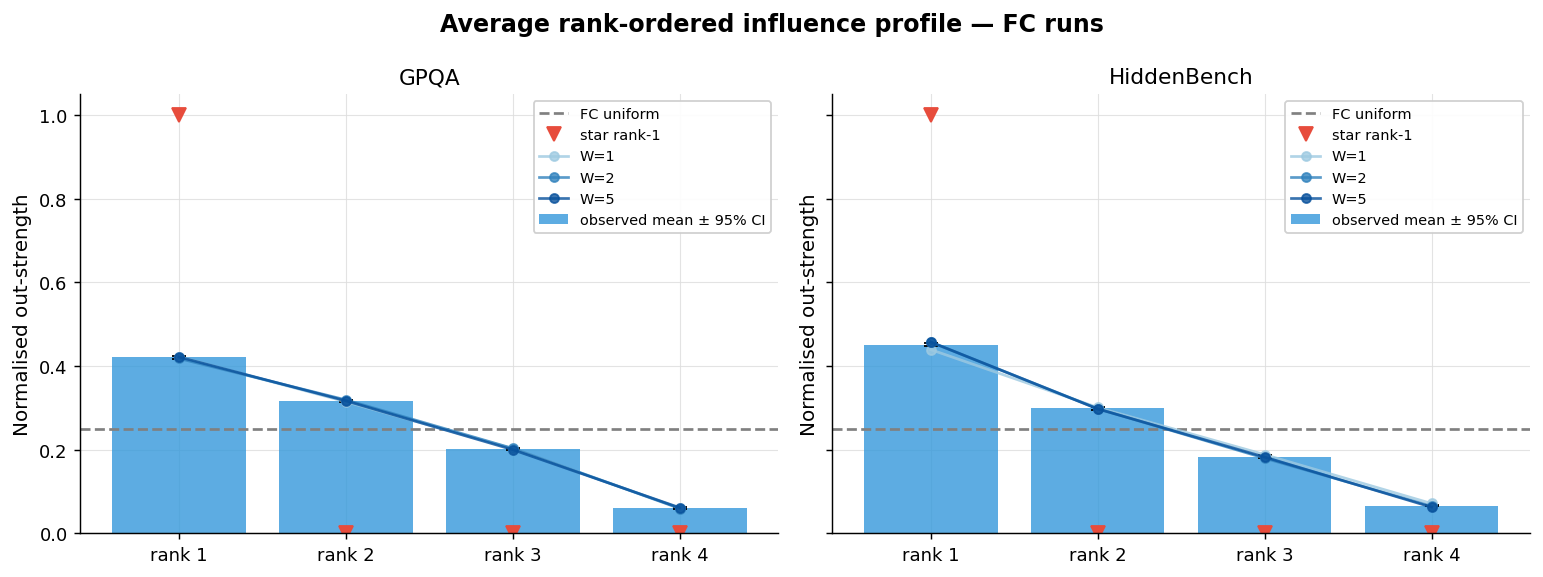

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
N_agents  = 4
ranks     = [f'rank {i+1}' for i in range(N_agents)]

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub = df_valid[df_valid['dataset'] == ds]
    profiles = np.array(sub['p_sorted'].tolist())  # shape (n_reps, N)

    mean_p = profiles.mean(axis=0)
    sem_p  = sp_stats.sem(profiles, axis=0)

    x = np.arange(N_agents)
    ax.bar(x, mean_p, yerr=1.96*sem_p, capsize=4, color='#3498db', alpha=0.8,
           error_kw=dict(lw=1.5), label='observed mean ± 95% CI')

    ax.axhline(1/N_agents, ls='--', lw=1.5, color='grey',  label='FC uniform')
    ax.plot([0], [1.0], 'v', ms=8, color='#e74c3c', label='star rank-1')
    ax.plot(x[1:], [0]*(N_agents-1), 'v', ms=8, color='#e74c3c')

    for w in [1, 2, 5]:
        wp = np.array(sub[sub['W_param'] == w]['p_sorted'].tolist()).mean(axis=0)
        ax.plot(x, wp, marker='o', ms=5, lw=1.5, label=f'W={w}', color=W_COLORS[w], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(ranks)
    ax.set_ylabel('Normalised out-strength')
    ax.set_title(f'{DS_LABELS[ds]}')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

fig.suptitle('Average rank-ordered influence profile — FC runs', fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Topology type × accuracy

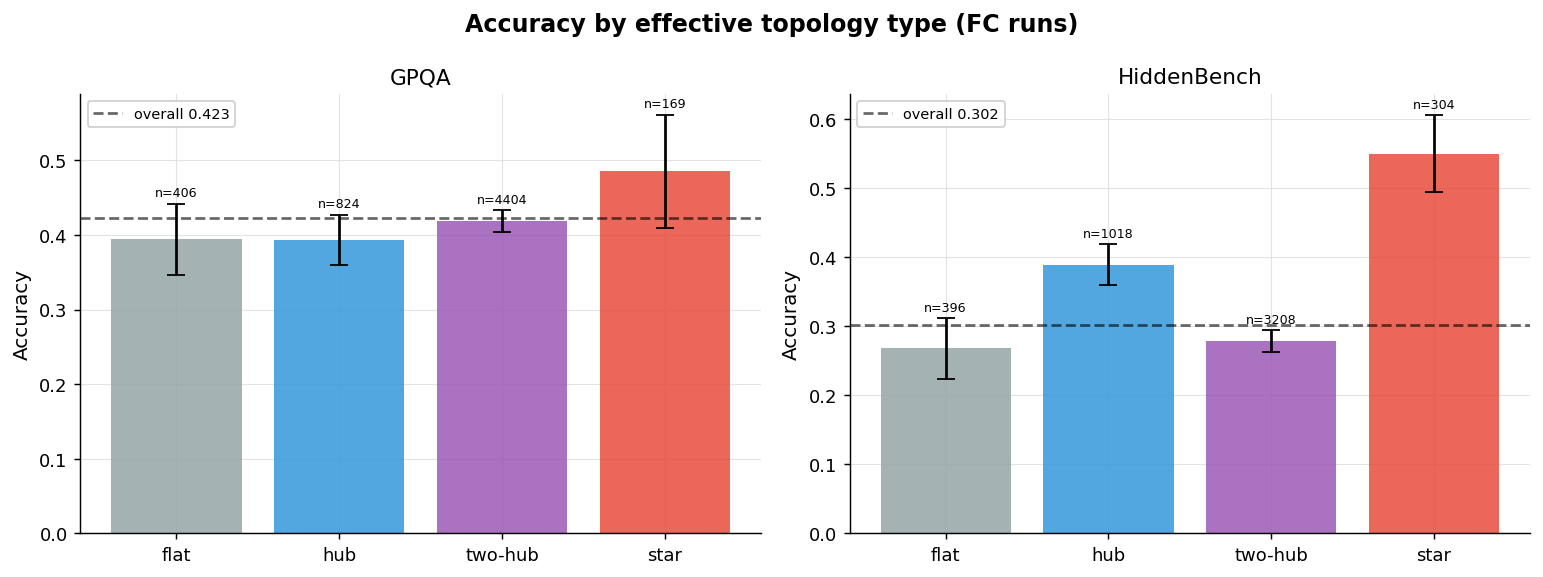


Spearman corr hub_frac vs correct:
  GPQA          rho=-0.018  p=1.816e-01  n=5,803
  HiddenBench   rho=+0.197  p=4.162e-44  n=4,926


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
plot_types = ['flat', 'hub', 'two-hub', 'star']

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub   = df[df['dataset'] == ds]
    means = []
    cis   = []
    ns    = []
    for t in plot_types:
        vals = sub[sub['ttype'] == t]['correct'].values
        if len(vals) == 0:
            means.append(np.nan); cis.append(np.nan); ns.append(0)
            continue
        m = vals.mean()
        ci = 1.96 * np.sqrt(m*(1-m)/len(vals))
        means.append(m); cis.append(ci); ns.append(len(vals))

    x      = np.arange(len(plot_types))
    colors = [TYPE_COLORS[t] for t in plot_types]
    bars   = ax.bar(x, means, yerr=cis, capsize=5, color=colors, alpha=0.85,
                    error_kw=dict(lw=1.5))

    for xi, (m, n) in enumerate(zip(means, ns)):
        if not np.isnan(m):
            ax.text(xi, m + cis[xi] + 0.01, f'n={n}', ha='center', fontsize=7)

    overall = sub['correct'].mean()
    ax.axhline(overall, ls='--', lw=1.5, color='black', alpha=0.6, label=f'overall {overall:.3f}')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_types)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{DS_LABELS[ds]}')
    ax.legend(fontsize=8)

fig.suptitle('Accuracy by effective topology type (FC runs)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSpearman corr hub_frac vs correct:')
for ds in ['gpqa', 'hiddenbench']:
    sub = df_valid[df_valid['dataset'] == ds]
    r, p = sp_stats.spearmanr(sub['hub_frac'], sub['correct'])
    print(f'  {DS_LABELS[ds]:12s}  rho={r:+.3f}  p={p:.3e}  n={len(sub):,}')

## 6 · Hub = agent who started correct?

Does the effective hub tend to be the agent that held the correct answer at round 0?

In [32]:
print('Hub-init-correct rate by topology type and dataset:')
print(df_valid.groupby(['dataset', 'ttype'])['hub_init_correct'].agg(['mean','count']).round(3).to_string())

print()
print('Chance baseline: fraction of reps where at least one agent starts correct (oracle rate):')
for ds in ['gpqa', 'hiddenbench']:
    sub = df[df['dataset'] == ds]
    any_correct = sub['init_votes'].apply(lambda v: sub.loc[sub.index[0],'gt'] in v)
    sub2 = df[df['dataset'] == ds].copy()
    has_correct_at_0 = sub2.apply(lambda r: r['gt'] in r['init_votes'], axis=1)
    chance = 1/4  # one agent picked correctly at random
    obs   = sub2[has_correct_at_0]['hub_init_correct'].mean()
    print(f'  {DS_LABELS[ds]:12s}  when correct present: hub_init_correct={obs:.3f}  (chance 1/N=0.25)')

Hub-init-correct rate by topology type and dataset:
                      mean  count
dataset     ttype                
gpqa        flat     0.310    406
            hub      0.336    824
            star     0.467    169
            two-hub  0.407   4404
hiddenbench flat     0.303    396
            hub      0.381   1018
            star     0.539    304
            two-hub  0.219   3208

Chance baseline: fraction of reps where at least one agent starts correct (oracle rate):
  GPQA          when correct present: hub_init_correct=0.573  (chance 1/N=0.25)
  HiddenBench   when correct present: hub_init_correct=0.579  (chance 1/N=0.25)


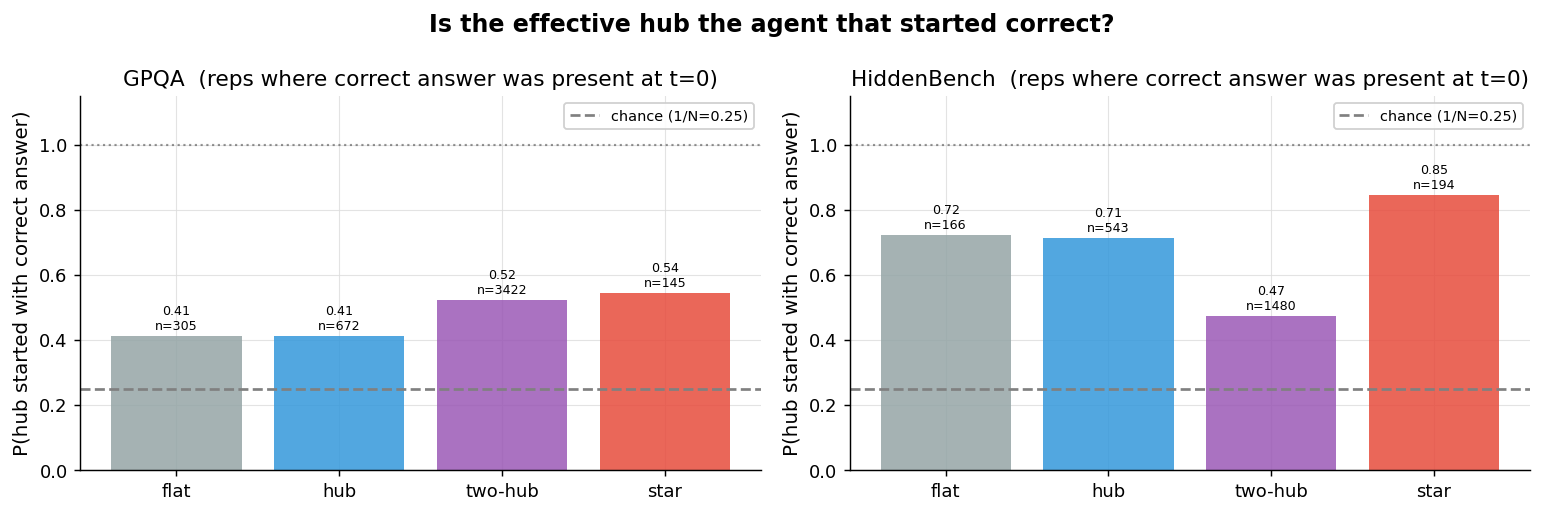

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ds in zip(axes, ['gpqa', 'hiddenbench']):
    sub  = df_valid[df_valid['dataset'] == ds].copy()
    sub['correct_present'] = sub.apply(lambda r: r['gt'] in r['init_votes'], axis=1)
    present = sub[sub['correct_present']]

    types_plot = [t for t in plot_types if t in present['ttype'].values]
    vals  = [present[present['ttype'] == t]['hub_init_correct'].mean() for t in types_plot]
    ns    = [present[present['ttype'] == t]['hub_init_correct'].count() for t in types_plot]

    ax.bar(types_plot, vals, color=[TYPE_COLORS[t] for t in types_plot], alpha=0.85)
    ax.axhline(0.25, ls='--', lw=1.5, color='grey', label='chance (1/N=0.25)')
    ax.axhline(1.00, ls=':', lw=1.2, color='black', alpha=0.4)
    for xi, (v, n) in enumerate(zip(vals, ns)):
        ax.text(xi, v + 0.02, f'{v:.2f}\nn={n}', ha='center', fontsize=7)
    ax.set_ylabel('P(hub started with correct answer)')
    ax.set_title(f'{DS_LABELS[ds]}  (reps where correct answer was present at t=0)')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

fig.suptitle('Is the effective hub the agent that started correct?', fontweight='bold')
plt.tight_layout()
plt.show()

## 7 · Two-hub (bipartite) structure

In a two-hub run, two agents each pull votes in different directions.
Does the winning hub (hub at the correct answer) correlate with outcome?

In [34]:
twohub = df_valid[df_valid['ttype'] == 'two-hub'].copy()
print(f'Two-hub runs: {len(twohub):,}  ({100*len(twohub)/len(df_valid):.1f}% of valid FC)')
print(twohub.groupby('dataset')[['correct','hub_init_correct','hub_final_correct']].mean().round(3).to_string())

print()
print('hub_frac distribution in two-hub runs:')
print(twohub.groupby('dataset')['hub_frac'].describe().round(3).to_string())
print()
print('second_frac / hub_frac ratio (how equal are the two hubs):')
twohub['balance'] = twohub['second_frac'] / twohub['hub_frac']
print(twohub.groupby('dataset')['balance'].describe().round(3).to_string())

Two-hub runs: 7,612  (70.9% of valid FC)
             correct  hub_init_correct  hub_final_correct
dataset                                                  
gpqa           0.418             0.407              0.419
hiddenbench    0.278             0.219              0.278

hub_frac distribution in two-hub runs:
              count   mean    std   min    25%    50%    75%    max
dataset                                                            
gpqa         4404.0  0.376  0.067  0.25  0.333  0.333  0.412  0.598
hiddenbench  3208.0  0.380  0.064  0.25  0.333  0.349  0.417  0.597

second_frac / hub_frac ratio (how equal are the two hubs):
              count   mean    std   min    25%  50%  75%  max
dataset                                                      
gpqa         4404.0  0.938  0.104  0.65  0.903  1.0  1.0  1.0
hiddenbench  3208.0  0.922  0.111  0.65  0.841  1.0  1.0  1.0


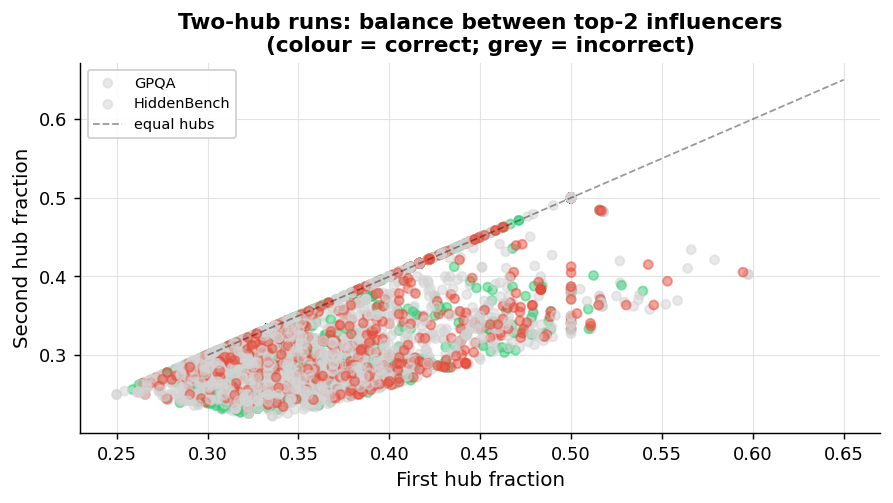

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))

for ds, color in zip(['gpqa', 'hiddenbench'], ['#2ecc71', '#e74c3c']):
    sub = twohub[twohub['dataset'] == ds]
    ax.scatter(sub['hub_frac'], sub['second_frac'],
               c=[color if c else 'lightgrey' for c in sub['correct']],
               alpha=0.5, s=25, label=DS_LABELS[ds])

ax.plot([0.3, 0.65], [0.3, 0.65], 'k--', lw=1, alpha=0.4, label='equal hubs')
ax.set_xlabel('First hub fraction')
ax.set_ylabel('Second hub fraction')
ax.set_title('Two-hub runs: balance between top-2 influencers\n(colour = correct; grey = incorrect)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8 · Round-by-round topology evolution

How does the effective topology build up over rounds?
We compute a cumulative W[0:t] at each round t and track hub_frac over time.

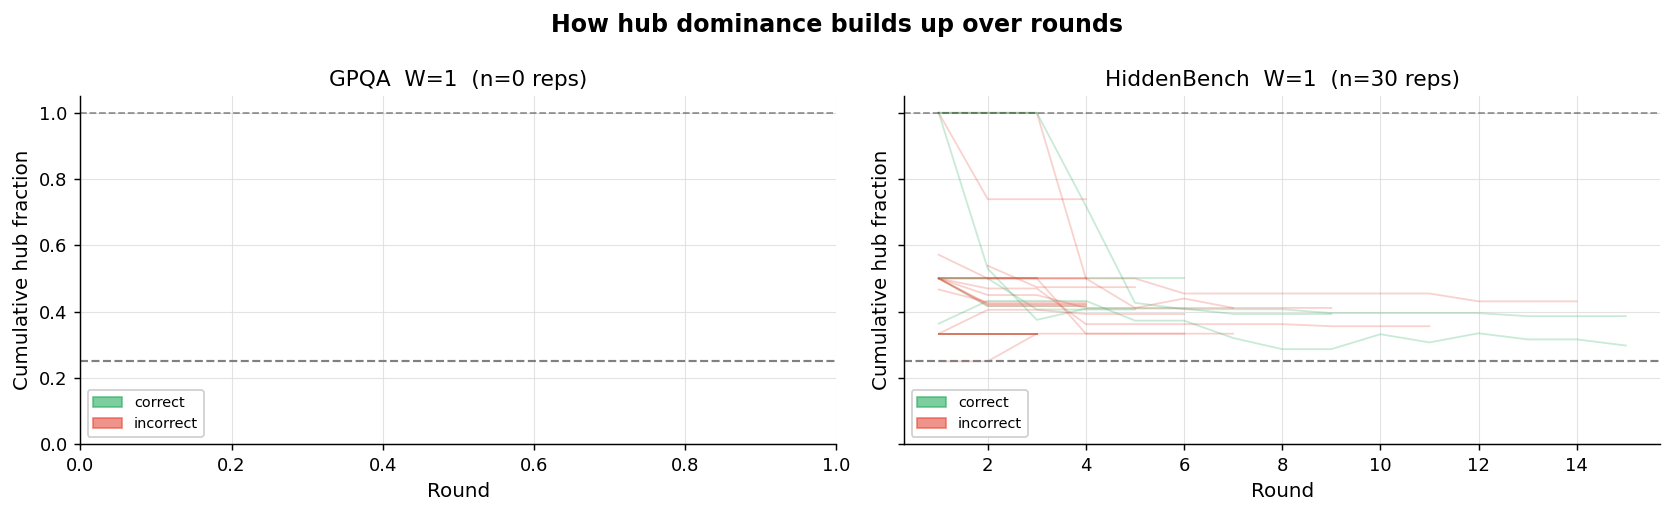

In [36]:
def cumulative_hub_frac_series(traj, topology):
    N   = len(traj[0]['phase_b'])
    W_t = np.zeros((N, N), dtype=float)
    series = []
    for t in range(len(traj) - 1):
        phase      = traj[t]['phase_b']
        next_phase = traj[t + 1]['phase_b']
        for j in range(N):
            v_next = next_phase[j]['vote']
            if v_next == phase[j]['vote']:
                continue
            c_j = phase[j].get('confidence') or 0.0
            nbrs = [k for k, v in enumerate(topology[j]) if v]
            elig = [k for k in nbrs if phase[k]['vote'] == v_next]
            if not elig:
                continue
            for i in elig:
                W_t[i, j] += c_j / len(elig)
        s    = W_t.sum(axis=1)
        tot  = s.sum()
        series.append(float(s.max() / tot) if tot > 0 else np.nan)
    return series


N_TRACE = 30
traces_gpqa = []
traces_hb   = []

for _, row in df_valid[df_valid['W_param'] == 1].head(N_TRACE * 2).iterrows():
    traj = traj_store[row['row_idx']]
    rep  = {'trajectory': traj,
            'topology': [[1 if j != i else 0 for j in range(4)] for i in range(4)]}  # fc
    series = cumulative_hub_frac_series(traj, rep['topology'])
    if row['dataset'] == 'gpqa' and len(traces_gpqa) < N_TRACE:
        traces_gpqa.append((series, row['correct']))
    elif row['dataset'] == 'hiddenbench' and len(traces_hb) < N_TRACE:
        traces_hb.append((series, row['correct']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, traces, ds in zip(axes, [traces_gpqa, traces_hb], ['gpqa', 'hiddenbench']):
    for series, correct in traces:
        color = '#27ae60' if correct else '#e74c3c'
        ax.plot(range(1, len(series)+1), series, color=color, alpha=0.25, lw=1)
    ax.axhline(0.25, ls='--', color='grey', lw=1.2, label='FC uniform')
    ax.axhline(1.00, ls='--', color='black', lw=1.0, alpha=0.4, label='pure star')
    correct_patch = mpatches.Patch(color='#27ae60', alpha=0.6, label='correct')
    wrong_patch   = mpatches.Patch(color='#e74c3c', alpha=0.6, label='incorrect')
    ax.legend(handles=[correct_patch, wrong_patch], fontsize=8)
    ax.set_xlabel('Round')
    ax.set_ylabel('Cumulative hub fraction')
    ax.set_title(f'{DS_LABELS[ds]}  W=1  (n={len(traces)} reps)')
    ax.set_ylim(0, 1.05)

fig.suptitle('How hub dominance builds up over rounds', fontweight='bold')
plt.tight_layout()
plt.show()

## 9 · Degenerate runs: what happened?

In [37]:
degen = df[df['ttype'] == 'degenerate'].copy()
print(f'Degenerate runs (zero influence): {len(degen):,}  ({100*len(degen)/len(df):.1f}%)')
print('n_rounds distribution:', degen['n_rounds'].value_counts().sort_index().to_dict())
print('correct rate:', degen['correct'].mean().round(3))
print('by dataset:', degen.groupby('dataset')[['correct','n_rounds']].mean().round(3).to_string())
print()
print('Are they runs where agents never changed vote?')
for _, row in degen.head(3).iterrows():
    traj = traj_store[row['row_idx']]
    N    = len(traj[0]['phase_b'])
    votes_by_round = [[traj[t]['phase_b'][i]['vote'] for i in range(N)] for t in range(len(traj))]
    print(f'  qid={row["qid"]} rep={row["rep_idx"]} rounds={len(traj)-1} votes={votes_by_round}')

Degenerate runs (zero influence): 2,021  (15.9%)
n_rounds distribution: {2: 2014, 3: 2, 15: 5}
correct rate: 0.389
by dataset:              correct  n_rounds
dataset                       
gpqa           0.450     2.000
hiddenbench    0.071     2.207

Are they runs where agents never changed vote?
  qid=1 rep=3 rounds=2 votes=[['C', 'C', 'C', 'C'], ['C', 'C', 'C', 'C'], ['C', 'C', 'C', 'C']]
  qid=1 rep=15 rounds=2 votes=[['C', 'C', 'C', 'C'], ['C', 'C', 'C', 'C'], ['C', 'C', 'C', 'C']]
  qid=1 rep=31 rounds=2 votes=[['C', 'C', 'C', 'C'], ['C', 'C', 'C', 'C'], ['C', 'C', 'C', 'C']]


## 11 · Initial vote split drives topology type

The initial vote distribution explains most of the variance in effective topology:
- **(3,1)** or **(2,1,1)** → more likely to produce star (lone outlier becomes hub)
- **(2,2)** → almost always produces two-hub (co-champions split the conversion credit)

**Star runs:** 61% start with exactly 1 correct agent — the "lone hero" who converts all others.

**Two-hub (2,2) runs:** {0: ~1172, 2: ~1174} correct agents at t=0 — literally the correct
faction vs the incorrect faction fighting for dominance.

In [38]:
from collections import Counter

split_records = []
for row_idx_local, row in df.iterrows():
    traj = traj_store[row['row_idx']]
    N    = len(traj[0]['phase_b'])
    init = row['init_votes']
    split = tuple(sorted(Counter(init).values(), reverse=True))
    n_correct_at_0 = sum(v == row['gt'] for v in init)
    split_records.append({
        'row_idx':  row['row_idx'],
        'ttype':    row['ttype'],
        'split':    str(split),
        'correct':  row['correct'],
        'n_correct_at_0': n_correct_at_0,
        'dataset':  row['dataset'],
        'W_param':  row['W_param'],
    })

df_split = pd.DataFrame(split_records)

print('Topology type by initial vote split (% of each split that becomes each type):')
ct = df_split.groupby(['split', 'ttype']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print(ct_pct.round(1).to_string())
print()
print('Accuracy by (split, ttype):')
acc = df_split.groupby(['split', 'ttype'])['correct'].agg(['mean','count'])
print(acc.round(3).to_string())

Topology type by initial vote split (% of each split that becomes each type):
ttype         degenerate  flat   hub  star  two-hub
split                                              
(1, 1, 1, 1)         0.0   6.0  36.0  22.7     35.3
(2, 1, 1)            0.0   5.0  22.6   6.7     65.7
(2, 2)               0.1   4.1   6.1   0.5     89.3
(3, 1)               0.1  10.9  19.2   4.5     65.3
(4,)                94.6   0.5   0.8   0.4      3.8

Accuracy by (split, ttype):
                          mean  count
split        ttype                   
(1, 1, 1, 1) flat        0.444      9
             hub         0.259     54
             star        0.471     34
             two-hub     0.283     53
(2, 1, 1)    flat        0.379    153
             hub         0.441    694
             star        0.580    205
             two-hub     0.374   2018
(2, 2)       degenerate  0.667      3
             flat        0.352    108
             hub         0.384    159
             star        0.667     

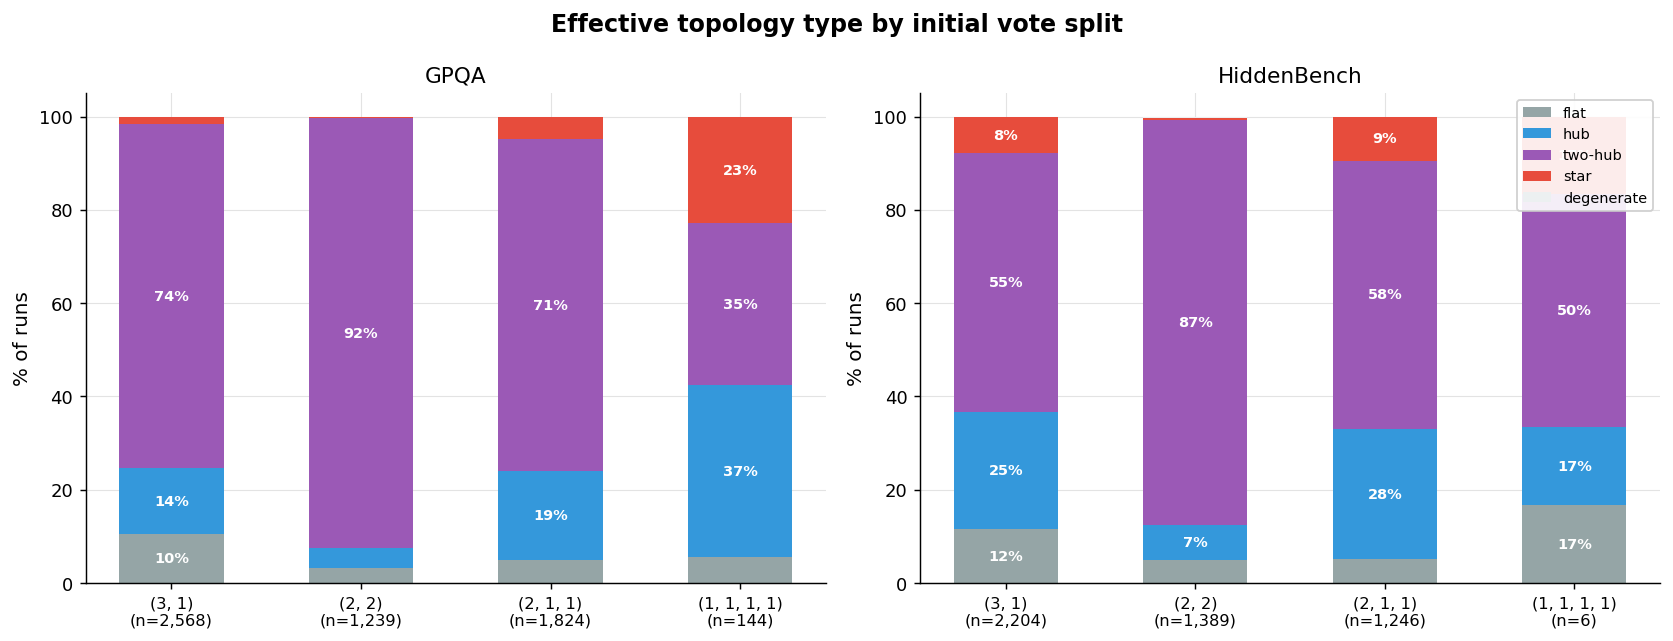

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

splits_plot = ['(3, 1)', '(2, 2)', '(2, 1, 1)', '(1, 1, 1, 1)']
types_plot2 = ['flat', 'hub', 'two-hub', 'star', 'degenerate']

for ax_idx, ds in enumerate(['gpqa', 'hiddenbench']):
    ax   = axes[ax_idx]
    sub  = df_split[df_split['dataset'] == ds]
    ct_s = sub.groupby(['split', 'ttype']).size().unstack(fill_value=0)
    ct_s = ct_s.reindex(index=[s for s in splits_plot if s in ct_s.index],
                         columns=[t for t in types_plot2 if t in ct_s.columns], fill_value=0)
    ct_p = ct_s.div(ct_s.sum(axis=1), axis=0) * 100

    x = np.arange(len(ct_p))
    bottom = np.zeros(len(ct_p))
    for ttype in ct_p.columns:
        vals = ct_p[ttype].values
        ax.bar(x, vals, bottom=bottom, color=TYPE_COLORS.get(ttype, 'grey'), label=ttype, width=0.55)
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 6:
                ax.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

    ns = ct_s.sum(axis=1).values
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\n(n={n:,})' for s, n in zip(ct_p.index, ns)], fontsize=9)
    ax.set_ylabel('% of runs')
    ax.set_title(f'{DS_LABELS[ds]}')
    ax.set_ylim(0, 105)
    if ax_idx == 1:
        ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Effective topology type by initial vote split', fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
print('=== LONE HERO PATTERN: star topology ===')
star_rows = df_split[df_split['ttype'] == 'star'].copy()
print(f'n={len(star_rows)}  acc={star_rows["correct"].mean():.3f}')
print('n_correct_at_0 distribution:')
print(star_rows['n_correct_at_0'].value_counts().sort_index().to_dict())
lone = star_rows[star_rows['n_correct_at_0'] == 1]
print(f'Lone correct (n_correct=1): {len(lone)} = {100*len(lone)/len(star_rows):.1f}%  acc={lone["correct"].mean():.3f}')
print()
print('=== FACTION BATTLE: two-hub (2,2) split ===')
th22 = df_split[(df_split['ttype'] == 'two-hub') & (df_split['split'] == '(2, 2)')].copy()
print(f'n={len(th22)}  acc={th22["correct"].mean():.3f}')
print('n_correct_at_0 distribution (expect 0 or 2 for binary questions):')
print(th22['n_correct_at_0'].value_counts().sort_index().to_dict())
correct_faction = th22[th22['n_correct_at_0'] == 2]
wrong_faction   = th22[th22['n_correct_at_0'] == 0]
print(f'Correct faction present (n_correct=2): {len(correct_faction)}  acc={correct_faction["correct"].mean():.3f}')
print(f'No correct at start (n_correct=0):     {len(wrong_faction)}   acc={wrong_faction["correct"].mean():.3f}')
print()
print('=== KEY CONTRAST ===')
print(f'Star (any split):          acc={star_rows["correct"].mean():.3f}')
print(f'Two-hub (2,2):             acc={th22["correct"].mean():.3f}')
print(f'Star (from 2,2 split):     acc={df_split[(df_split["ttype"]=="star") & (df_split["split"]=="(2, 2)")]["correct"].mean():.3f}  (star wins deadlock → correct)')

=== LONE HERO PATTERN: star topology ===
n=473  acc=0.526
n_correct_at_0 distribution:
{0: 134, 1: 291, 2: 32, 3: 16}
Lone correct (n_correct=1): 291 = 61.5%  acc=0.742

=== FACTION BATTLE: two-hub (2,2) split ===
n=2346  acc=0.351
n_correct_at_0 distribution (expect 0 or 2 for binary questions):
{0: 1172, 2: 1174}
Correct faction present (n_correct=2): 1174  acc=0.609
No correct at start (n_correct=0):     1172   acc=0.092

=== KEY CONTRAST ===
Star (any split):          acc=0.526
Two-hub (2,2):             acc=0.351
Star (from 2,2 split):     acc=0.667  (star wins deadlock → correct)


## 10 · Summary: key numbers

In [41]:
print('=== EFFECTIVE TOPOLOGY SUMMARY ===')
print()

for ds in ['gpqa', 'hiddenbench']:
    sub   = df[df['dataset'] == ds]
    valid = df_valid[df_valid['dataset'] == ds]
    print(f'{DS_LABELS[ds]}  (n={len(sub):,}, valid={len(valid):,})')
    print(f'  Degenerate (no flips):  {100*(sub["ttype"]=="degenerate").mean():.1f}%')
    for t in plot_types:
        frac = 100*(sub['ttype']==t).mean()
        acc  = sub[sub['ttype']==t]['correct'].mean()
        print(f'  {t:8s}: {frac:5.1f}%  acc={acc:.3f}')
    print(f'  hub_frac mean: {valid["hub_frac"].mean():.3f}  (FC uniform baseline = 0.25)')
    star_frac = (valid['hub_frac'] >= 0.75).mean()
    print(f'  Star-like (hub_frac≥0.75): {100*star_frac:.1f}% of valid runs')
    r, p = sp_stats.spearmanr(valid['hub_frac'], valid['correct'])
    print(f'  Spearman(hub_frac, correct): rho={r:+.3f}  p={p:.3e}')
    if len(valid) > 0:
        hic = valid[valid.apply(lambda r: r['gt'] in r['init_votes'], axis=1)]['hub_init_correct'].mean()
        print(f'  Hub started correct (when correct present): {hic:.3f}  (chance=0.25)')
    print()

=== EFFECTIVE TOPOLOGY SUMMARY ===

GPQA  (n=7,500, valid=5,803)
  Degenerate (no flips):  22.6%
  flat    :   5.4%  acc=0.394
  hub     :  11.0%  acc=0.393
  two-hub :  58.7%  acc=0.418
  star    :   2.3%  acc=0.485
  hub_frac mean: 0.421  (FC uniform baseline = 0.25)
  Star-like (hub_frac≥0.75): 2.9% of valid runs
  Spearman(hub_frac, correct): rho=-0.018  p=1.816e-01
  Hub started correct (when correct present): 0.501  (chance=0.25)

HiddenBench  (n=5,250, valid=4,926)
  Degenerate (no flips):  6.2%
  flat    :   7.5%  acc=0.268
  hub     :  19.4%  acc=0.389
  two-hub :  61.1%  acc=0.278
  star    :   5.8%  acc=0.549
  hub_frac mean: 0.451  (FC uniform baseline = 0.25)
  Star-like (hub_frac≥0.75): 6.2% of valid runs
  Spearman(hub_frac, correct): rho=+0.197  p=4.162e-44
  Hub started correct (when correct present): 0.577  (chance=0.25)

